In [50]:
# THE PLAN PART 1:
#    Send a ADQL query to the Gaia archive, 
#    asking it to return all the stars in a small patch of sky around NGC 2244,
#    Then, trimming down the data set for qualifying canadates

#    NGC 2244    RA: 06h 32m 18s , DEC +04° 52′ 00″

#    NGC 2244 itself spans about 30 arcminutes (0.5°), 
#        So we may want to search radius around 1 degree, 
#        giving us a generous field around the cluster 
#        this would give field-star background for contrast


In [2]:
pip install astroquery


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astroquery
from astroquery.gaia import Gaia
import os

In [17]:
tables = Gaia.load_tables()

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]


In [18]:
#    These are the table names from our dataset
for i, tab in enumerate(tables):
    print (i, tab.name)

0 external.apassdr9
1 external.catwise2020
2 external.gaiadr2_astrophysical_parameters
3 external.gaiadr2_geometric_distance
4 external.gaiaedr3_distance
5 external.gaiaedr3_gcns_main_1
6 external.gaiaedr3_gcns_rejected_1
7 external.gaiaedr3_spurious
8 external.gaia_eso_survey
9 external.galex_ais
10 external.lamost_dr9_lrs
11 external.lamost_dr9_mrs
12 external.ravedr5_com
13 external.ravedr5_dr5
14 external.ravedr5_gra
15 external.ravedr5_on
16 external.ravedr6
17 external.sdssdr13_photoprimary
18 external.skymapperdr1_master
19 external.skymapperdr2_master
20 external.tmass_xsc
21 external.xgboost_table1
22 external.xgboost_table2
23 gaiadr1.aux_qso_icrf2_match
24 gaiadr1.ext_phot_zero_point
25 gaiadr1.allwise_best_neighbour
26 gaiadr1.allwise_neighbourhood
27 gaiadr1.gsc23_best_neighbour
28 gaiadr1.gsc23_neighbourhood
29 gaiadr1.ppmxl_best_neighbour
30 gaiadr1.ppmxl_neighbourhood
31 gaiadr1.sdss_dr9_best_neighbour
32 gaiadr1.sdss_dr9_neighbourhood
33 gaiadr1.tmass_best_neighbour
34

In [19]:
#    We're interested in the "gaiadr3.gaia_source" table, this is entry 94. 
#    We can also see what columns are included in this table:

In [20]:
cols = tables[94].columns
for col in cols:
    print (col.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [21]:
#    Such Cool Much WoW

In [22]:
#    Here is my example query for
#        Finding the 100 brightest stars anywhere in the entire sky
#        that are within 200 parsecs of Earth with some quality cuts


#query_size = 100  # Number of stars we want to get was 100000
#distance = 200  # Distance (in pc) out to which we will query
#job = Gaia.launch_job_async("select top {}".format(query_size)+
#                 " ra, dec, parallax, parallax_over_error, "   # Getting source location and parallax
#                 " bp_rp, phot_g_mean_mag "                    # Getting color and magnitude measurements
#                 " from gaiadr3.gaia_source"                   # Selecting the data source
#                 # All of these are data quality checks
#                 " where parallax_over_error > 10"
#                 " and visibility_periods_used > 8"
#                 " and phot_g_mean_flux_over_error > 50"
#                 " and phot_bp_mean_flux_over_error > 20"
#                 " and phot_rp_mean_flux_over_error > 20"
#                 " and phot_bp_rp_excess_factor <"
#                 " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
#                 " and phot_bp_rp_excess_factor >"
#                 " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
#                 " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
#                 "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"
#                 # Filtering on distance
#                 +" and 1000/parallax <= {}".format(distance))


#r = job.get_results()
##  Convert to pandas
#df = r.to_pandas()
# # Save to a csv
#df.to_csv("gaia3.csv")

In [23]:
#    Lets rewrite this query to do a cone search around NGC 2244,
#    include the source id, mra, pmdec, ruwe), andmra, pmdec, ruwe),
#    and uses phot_g_mean_mag < 18, parallax_over_error > 5, ruwe < 1.4
#        Cone Searches:
#            ADQL has a function for cone searches,
#            CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS',
#            center_ra, center_dec, radius)) = 1
#
#        Here we give the star's position as POINT,
#        take a circle (using center coordinates and the radius in degrees,
#        It will return 1 if the star is inside the circle


In [35]:
if os.path.exists("gaia3.csv"):    # Check if we already have a cached copy of the Gaia query results
    # Cached file exists, load it directly from disk
    df = pd.read_csv("gaia3.csv")
    print(f"Loaded {len(df)} stars from cached CSV")
else:
    # No cached file, so we need to run the query
    print("No cached data found, running Gaia query...")




    #Gaia.ROW_LIMIT = -1    # So turns out there is a row limit, this bypasses it, but i'm scared, so will add later
                            #If you want a limit, you can set like Gaia.ROW_LIMIT = 100000

    
    # ***** Kinda Important, when we're ready to pull all the stars, changed row limit
    #       Change .csv filename so we do not overwrite our test sample
    Gaia.ROW_LIMIT = 2000
    job = Gaia.launch_job("select"
                     " ra, dec, parallax, parallax_over_error, "   # Getting source location and parallax
                     " bp_rp, phot_g_mean_mag, "                   # Getting color and magnitude measurements
                     " source_id, pmra, pmdec, ruwe "              # Getting source_id, proper motion and ruwe
                     " from gaiadr3.gaia_source"                   # Selecting the data source
                     # All of these are data quality checks
                     " where parallax_over_error > 5"
                     " and CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 98.075, 4.867, 1.0)) = 1"
                     " and visibility_periods_used > 8"
                     " and phot_g_mean_mag < 18"
                     " and ruwe < 1.4"
                     #" and phot_g_mean_flux_over_error > 18"    # maybe remove, as ruwe < 1.4 cleans data
                     #" and phot_bp_mean_flux_over_error > 20"   # maybe remove, as ruwe < 1.4 cleans data
                     #" and phot_rp_mean_flux_over_error > 20"  # maybe remove, as ruwe < 1.4 cleans data
                        )


    r = job.get_results()
    #  Convert to pandas
    df = r.to_pandas()
    # Save to a csv
    df.to_csv("gaia3.csv", index=False)
    print(f"Query complete: pulled {len(df)} stars and saved to gaia3.csv")

Loaded 2000 stars from cached CSV


In [36]:
import pandas as pd
df = pd.read_csv("gaia3.csv")
df.head()

,ra,dec,parallax,parallax_over_error,bp_rp,phot_g_mean_mag,source_id,pmra,pmdec,ruwe
0,98.070497,3.873386,1.066873,14.943256,1.491985,16.566626,3130400455725120256,-3.288058,-1.845925,1.216265
1,98.029188,3.876715,0.871130,6.945155,1.841495,17.753311,3130400623227260288,1.142605,-3.403864,0.981098
2,97.947372,3.883964,1.156639,29.064032,1.351256,15.416077,3130401177279654144,0.066315,-3.306818,1.040732
3,97.959000,3.912586,0.827174,28.323586,1.185839,14.678824,3130401383438071040,-5.583062,-2.497265,0.949203
4,98.006924,3.903572,1.178358,11.686741,1.748117,17.059366,3130401447860997376,2.067677,1.945877,1.203467


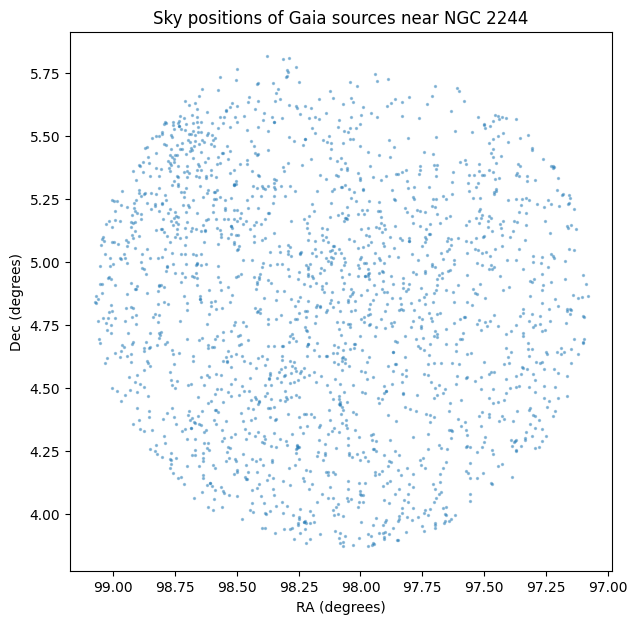

In [47]:
# Lets check out our data, and make sure we're not failures
# Plotting sky positions

plt.figure(figsize=(7, 7))
plt.scatter(df['ra'], df['dec'], s=2, alpha=0.4)
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.title('Sky positions of Gaia sources near NGC 2244')
plt.gca().invert_xaxis()  # RA increases to the left in sky maps
plt.show()

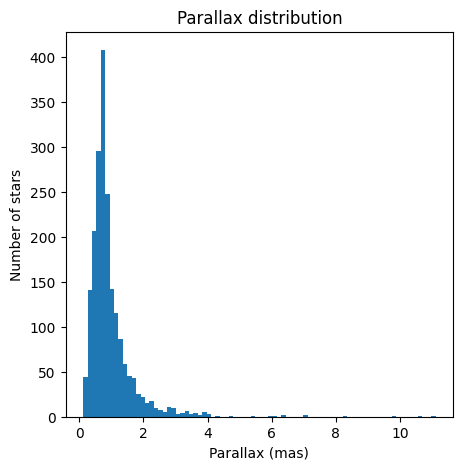

In [48]:
# Lets make a parallax histogram
# NGC 2244 is at ~1400 pc, which corresponds to a parallax of about 0.7 mas
# mas ≈ 1000 / distance

plt.figure(figsize=(5, 5))
plt.hist(df['parallax'], bins=80)
plt.xlabel('Parallax (mas)')
plt.ylabel('Number of stars')
plt.title('Parallax distribution')
plt.show()

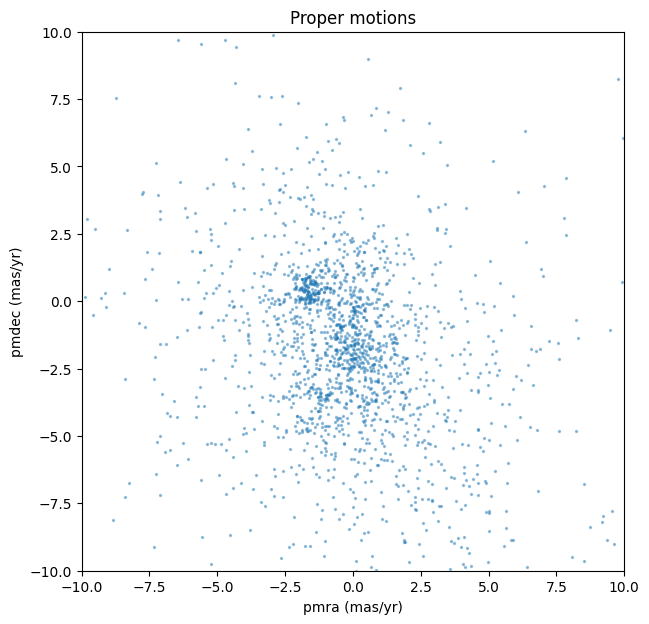

In [59]:
# Lets make a proper motion scatter plot
# Since we're looking at a cluster, we should expect tightly grouped PMs
# NGC 2244's proper motion is roughly (pmra, pmdec) = (-1.7, +0.3) mas/yr

plt.figure(figsize=(7, 7))
plt.scatter(df['pmra'], df['pmdec'], s=2, alpha=0.4)
plt.xlabel('pmra (mas/yr)')
plt.ylabel('pmdec (mas/yr)')
plt.title('Proper motions')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.show()

In [67]:
# THE PLAN PART 2:
#    Pull the astrometric features the GMM will cluster on
#    We're using only astrometry for now, we can later train the
#    Random Forest on photometry
#
#    We will then run the GMM from sklearn

features = df[['parallax', 'pmra', 'pmdec']].values    # .values converts pandas df into a numpy array
print(f"Feature matrix shape: {features.shape}")       # this is awesome as it is what scikitlearn expects

Feature matrix shape: (2000, 3)


In [63]:
# STANDARDIZE THE FEATURES
#    So our features are 
#    parallax in mas with a range of about (0.5, 2),
#    pmra / pmdec in mas/yr with a range of about (-10, 10),
#        A GMM uses distances in feature space
#        so a feature with a bigger numerical range will dominate the clustering
#    So, lets put the features on the same scale before clustering (Standardizing)
#
#    In scikit-learn, we can use StandardScaler
#        It subtracts the mean and divides by the standard deviation, 
#        so every feature ends up with mean 0 and standard deviation 1

In [62]:
from sklearn.preprocessing import StandardScaler

In [66]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print(f"Mean of each scaled feature: {features_scaled.mean(axis=0)}")  # should be near 0
print(f"Standard Deviation of each scaled feature: {features_scaled.std(axis=0)}")    # should be 1

Mean of each scaled feature: [ 1.49213975e-16 -8.88178420e-18  0.00000000e+00]
Standard Deviation of each scaled feature: [1. 1. 1.]


In [72]:
# RUN THE GAUSSIAN MIXTURE MODEL
#    We will use a GMM, a clustering algorithm that assumes the data is
#    a mixture of Gaussian distributions
#    We must tell it how many groups to look for
#    and it figures out where each one is centered, the range, and which data correlates to which group
#
#    We're using 2 components for our distributions
#        One for the tight clump of similar parallax and motion, cluster members
#        One for the loose cloud of random parallax and motion, field stars
#
#
#    After fitting using GaussianMixture, we get
#        labels, being a hard assignment (0 or 1) for each star's group
#        probs, probabilities for each star belonging to each group
#                  (probs[i] = [P(group 0), P(group 1)], and they sum to 1)
#
#    After we have our two groups, we will figure which is which by looking at the centroids

In [73]:
from sklearn.mixture import GaussianMixture

#    random_state=42 is a seed, GMM uses random starting points
#    so with a seed we can reproduce the same results

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(features_scaled)

labels = gmm.predict(features_scaled)

probs = gmm.predict_proba(features_scaled)

print(f"Number of stars in group 0: {(labels == 0).sum()}")
print(f"Number of stars in group 1: {(labels == 1).sum()}")

Number of stars in group 0: 1675
Number of stars in group 1: 325


In [ ]:
# Print the centroids of each component in the original units
# (we unscale them so they're human-readable)
centroids_scaled = gmm.means_
centroids = scaler.inverse_transform(centroids_scaled)

print("Component 0 centroid (parallax, pmra, pmdec):", centroids[0])
print("Component 1 centroid (parallax, pmra, pmdec):", centroids[1])